In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" # Ensures IDs match nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import random
from pathlib import Path

import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms

from PIL import Image

from preprocessing_module import find_class_names_filenames, stratified_split_data_paths, NatureCityScenesDataset
from trainer_class import Trainer

from ResNet import ResNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)

Device: cuda


In [3]:
DATASET_PATH = r"/itf-fi-ml/shared/courses/IN3310/mandatory1_data"

class_names, class_filenames = find_class_names_filenames(DATASET_PATH)
x_train_paths, x_val_paths, x_test_paths, y_train, y_val, y_test = stratified_split_data_paths(class_names, class_filenames)

train_set = NatureCityScenesDataset(DATASET_PATH, x_train_paths, y_train, transform=None)
val_set = NatureCityScenesDataset(DATASET_PATH, x_val_paths, y_val, transform=None)
test_set = NatureCityScenesDataset(DATASET_PATH, x_test_paths, y_test, transform=None)

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = NatureCityScenesDataset(DATASET_PATH, x_train_paths, y_train, transform=transform)
val_set = NatureCityScenesDataset(DATASET_PATH, x_val_paths, y_val, transform=transform)
test_set = NatureCityScenesDataset(DATASET_PATH, x_test_paths, y_test, transform=transform)

# --------------------------------------------------------------------------------------------------------------------------------

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

def batch_noise_augment(images: torch.Tensor, std: float = 0.03) -> torch.Tensor:
    noise = torch.randn_like(images) * std
    return torch.clamp(images + noise, -1.0, 1.0)

# --------------------------------------------------------------------------------------------------------------------------------

model_ResNet = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet.parameters(), lr=1e-4)

trainer_ResNet = Trainer(
    model=model_ResNet,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet.fit(train_loader, val_loader, epochs=num_epochs)

Epoch 01 | train loss: 0.7614, acc: 0.711 | val loss: 0.6755, acc: 0.752, mean average precision (mAP): 0.859, AP per class: [0.8076581  0.97749935 0.81097342 0.85983096 0.82044652 0.87654921]
Epoch 02 | train loss: 0.4683, acc: 0.831 | val loss: 0.5276, acc: 0.806, mean average precision (mAP): 0.900, AP per class: [0.88104042 0.98591224 0.85489685 0.87639686 0.89788203 0.90340821]
Epoch 03 | train loss: 0.3365, acc: 0.880 | val loss: 0.8124, acc: 0.754, mean average precision (mAP): 0.865, AP per class: [0.86229403 0.94266195 0.84870989 0.86664702 0.91709878 0.75352278]
Epoch 04 | train loss: 0.2360, acc: 0.920 | val loss: 0.9678, acc: 0.720, mean average precision (mAP): 0.826, AP per class: [0.8170099  0.9623245  0.83185875 0.68604133 0.84235885 0.81374844]
Epoch 05 | train loss: 0.1846, acc: 0.937 | val loss: 1.7039, acc: 0.606, mean average precision (mAP): 0.808, AP per class: [0.77199053 0.93869437 0.67547718 0.82107992 0.86407931 0.7767306 ]
Epoch 06 | train loss: 0.1236, acc:

In [4]:
trainer_ResNet.evaluate(test_loader)

EpochStats(loss=0.7488203917940458, acc=0.81744368125995, mAP=0.8970310096965647, AP_per_class=array([0.88652831, 0.97544898, 0.87961696, 0.85080365, 0.90847456,
       0.8813136 ]))

In [6]:
# Move results from GPU to memory
results_dict = trainer_ResNet.history

In [ ]:
# Clean as much as possible of the GPU memory
import gc
if 'trainer_ResNet' in globals():
    del trainer_ResNet

if 'model' in globals():
    del model_ResNet

# 2. Force Python to find and remove "orphaned" memory references
gc.collect()

# 3. IMPORTANT: Tell PyTorch to give the memory back to the GPU pool
# Without this, nvidia-smi will still show the memory as "Used"
torch.cuda.empty_cache()

In [ ]:
def plot_results(num_epochs, results_dict):

    epochs_list = np.arange(1, num_epochs+1)

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs_list, results_dict["train_loss"], '.-', label="train loss")
    plt.plot(epochs_list, results_dict["val_loss"], '.-', label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()    

    plt.subplot(2, 2, 2)
    plt.plot(epochs_list, results_dict["train_acc"], '.-', label="train acc")
    plt.plot(epochs_list, results_dict["val_acc"], '.-', label="val acc")
    plt.plot(epochs_list, results_dict["val_mAP"], '.-', label="val mAP")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(2, 1, 2) 
    hist_arr_val_AP_per_class = np.asarray(results_dict["val_AP_per_class"])
    for class_number, class_name in enumerate(class_names):
        plt.plot(epochs_list, hist_arr_val_AP_per_class[:, class_number], ".-", label=f"Class {class_number}: {class_name}")

    plt.xlabel("Epoch")
    plt.ylabel("Precision, validation set")
    plt.legend()
    plt.tight_layout()
    plt.show()

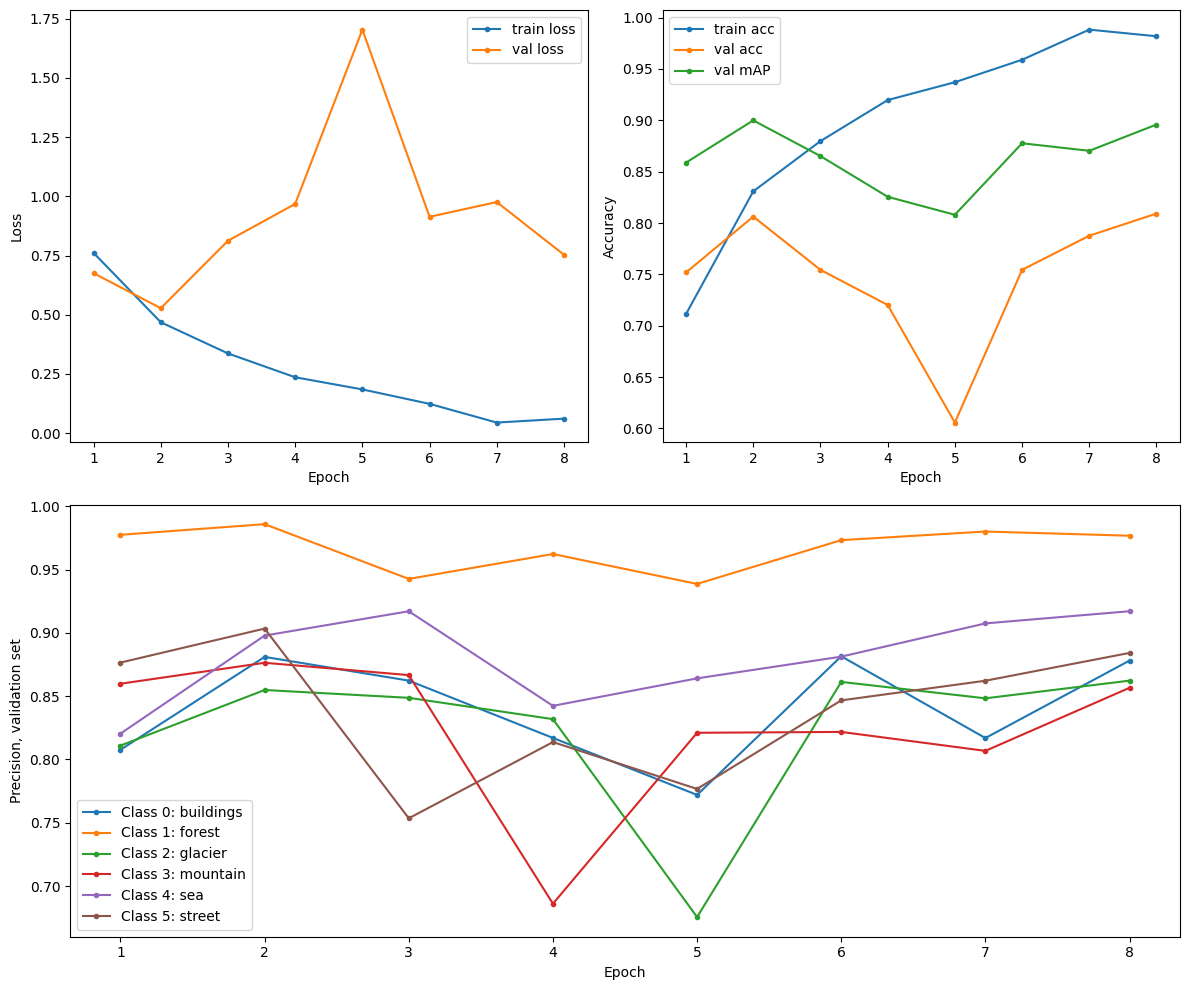

In [16]:
plot_results(num_epochs, results_dict)

In [ ]:
torch_model_resnet18 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /itf-fi-ml/home/johnmagj/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s] 


In [24]:
torch_model_resnet18.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  